In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
import scipy as sc

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Processed_files/')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# For plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
mplstyle.use(['ggplot', 'fast'])

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import LinearSegmentedColormap
from cmocean import cm as cmo
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

In [3]:
no_plates_20 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/no_plates_20cm.csv")
plates_20 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/plates_20cm.csv")
no_plates_30 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/no_plates_30cm.csv")
plates_30 = pd.read_csv("/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/plates_30cm.csv")

In [4]:
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])  # positions of probes in meters from wave maker
x_prof = x_probe_pos - x_probe_pos[0]  # positions of probes relative to the first probe

In [5]:
f_20 = no_plates_20["frequency"].unique()
f_30 = no_plates_30["frequency"].unique()

D_20 = 0.2
H_20 = 0.15
D_30 = 0.3
H_30 = 0.25

k_20 = []
for f in f_20:
    k_20.append(wave_number_in_theory(f, H_20))
    
k_30 = []
for f in f_30:
    k_30.append(wave_number_in_theory(f, H_30))

In [6]:
a_theory_20 = []
a_weber_20 = []

for k in k_20:
    t, w = spatial_damping_coefficient(k, D_20, H_20)
    a_theory_20.append(t)
    a_weber_20.append(w)

a_theory_30 = []
a_weber_30 = []

for k in k_30:
    t, w = spatial_damping_coefficient(k, D_30, H_30)
    a_theory_30.append(t)
    a_weber_30.append(w)

In [7]:
"""
Subtract the wall-effects from the damping coefficients observed with plates, to get the damping due to the plates alone. 
Then compare this to the theoretical predictions for damping by a thin plate.
"""

plates_20['alpha_plates'] = plates_20['alpha'] - no_plates_20['alpha']
plates_30['alpha_plates'] = plates_30['alpha'] - no_plates_30['alpha']

In [8]:
plates_20

,frequency,volt,volt_level,condition,run,ak,kH,amp_P0,amp_P1,amp_P2,amp_P3,se_P0,se_P1,se_P2,se_P3,alpha,se_alpha,R,alpha_plates
0,1.1,0.10,low,p005,R1,0.027376,1.177906,0.004648,0.004608,0.004413,0.004238,0.000039,0.000022,0.000004,0.000048,0.021984,0.005609,0.001120,0.007710
1,1.1,0.10,low,p005,R2,0.027908,1.177906,0.004739,0.004615,0.004366,0.004174,0.000033,0.000014,0.000013,0.000054,0.030322,0.005042,0.001545,0.019180
2,1.1,0.10,low,p005,R3,0.028126,1.177906,0.004776,0.004601,0.004396,0.004323,0.000030,0.000018,0.000012,0.000067,0.024410,0.002883,0.001243,0.015934
3,1.1,0.20,medium,p005,R1,0.055424,1.177906,0.009411,0.009143,0.008742,0.008326,0.000037,0.000046,0.000049,0.000072,0.028720,0.004360,0.001463,0.023353
4,1.1,0.20,medium,p005,R2,0.055363,1.177906,0.009400,0.009087,0.008778,0.008348,0.000036,0.000050,0.000051,0.000071,0.027346,0.003531,0.001393,0.022330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,1.8,0.25,medium-high,p005,R2,0.228878,2.634729,0.017374,0.017692,0.015897,0.015014,0.000068,0.000054,0.000038,0.000036,0.036685,0.014804,0.000835,-0.028998
77,1.8,0.25,medium-high,p005,R3,0.226398,2.634729,0.017186,0.017484,0.015936,NaN,0.000054,0.000044,0.000035,NaN,NaN,NaN,NaN,NaN
78,1.8,0.30,high,p005,R1,0.287682,2.634729,0.021838,0.019193,0.018300,NaN,0.000082,0.000069,0.000153,NaN,NaN,NaN,NaN,NaN
79,1.8,0.30,high,p005,R2,0.298430,2.634729,0.022654,0.018893,0.019227,NaN,0.000081,0.000085,0.000099,NaN,NaN,NaN,NaN,NaN


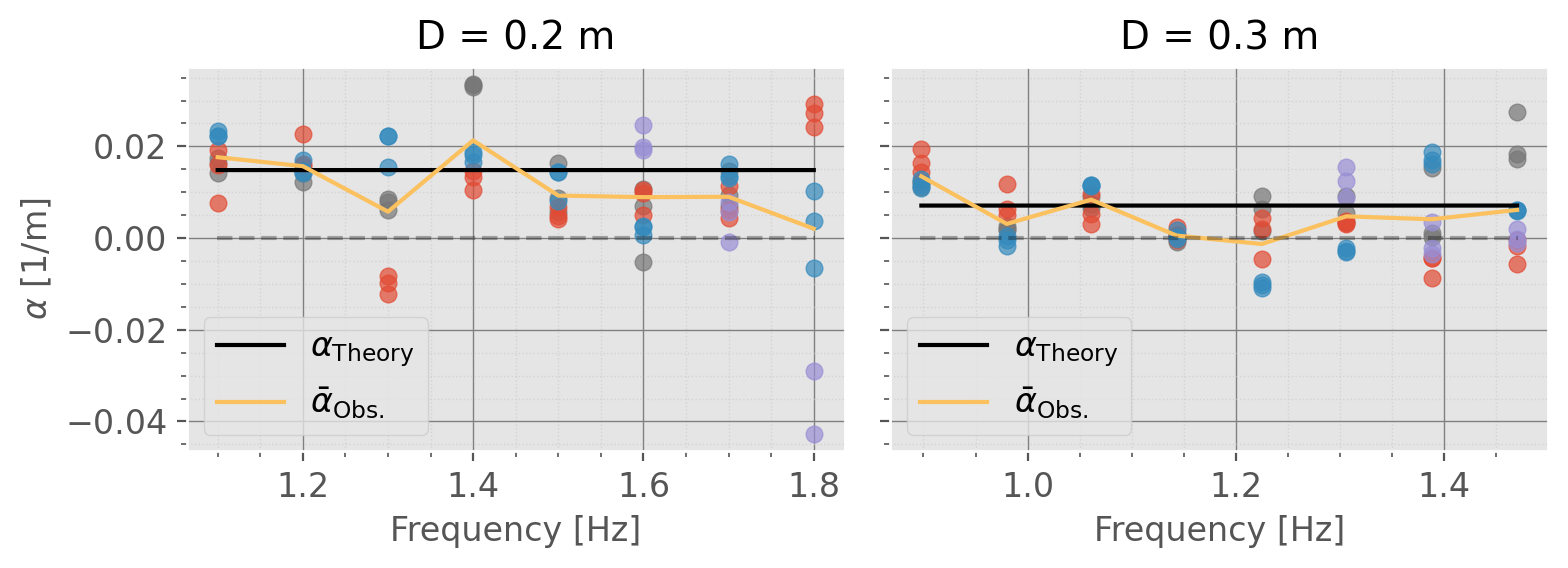

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

level_colors = {
    "low":  "C0",
    "medium":  "C1",
    "medium-high": "C2",
    "high": "C3",
}
ax[0].plot(f_20, np.array(a_theory_20), '-', color='black', label=r'$\alpha_{\text{Theory}}$')
ax[1].plot(f_30, np.array(a_theory_30), '-', color='black', label=r'$\alpha_{\text{Theory}}$')

for level, sub in plates_20.groupby("volt_level"):
    ax[0].scatter(sub["frequency"], sub["alpha_plates"],
               marker='o',
               alpha=0.7,
               color=level_colors.get(level, "gray"))

for level, sub in plates_30.groupby("volt_level"):
    ax[1].scatter(sub["frequency"], sub["alpha_plates"],
            alpha=0.7,
               marker='o',
               color=level_colors.get(level, "gray"))

ax[0].plot(f_20, plates_20.groupby('frequency')['alpha_plates'].mean(), color='C4', label=r'$\bar{\alpha}_{\text{Obs.}}$')
ax[1].plot(f_30, plates_30.groupby('frequency')['alpha_plates'].mean(), color='C4', label=r'$\bar{\alpha}_{\text{Obs.}}$')

""" ax[0].plot(plates_20['frequency'], plates_20['alpha_plates'], 'o', alpha=0.7, color='C0', label=r'$\alpha_{\text{Obs.}}$')
ax[1].plot(plates_30['frequency'], plates_30['alpha_plates'], 'o', alpha=0.7, color='C1', label=r'$\alpha_{\text{Obs.}}$')"""

ax[0].hlines(0, 1.099, 1.801, colors='k', linestyles='dashed', alpha=0.3)
ax[1].hlines(0, 0.897, 1.471, colors='k', linestyles='dashed', alpha=0.3)

ax[0].set_title('D = 0.2 m')
ax[1].set_title('D = 0.3 m')

ax[0].set_xlabel('Frequency [Hz]')
ax[1].set_xlabel('Frequency [Hz]')
ax[0].set_ylabel(r'$\alpha$ [1/m]')

ax[0].legend(loc='lower left')
ax[1].legend(loc='lower left')

for a in ax:
    a.minorticks_on()
    a.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
    a.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray') 

plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/alpha_obs_vs_theory.png", dpi=300)

## For fun

In [10]:
2*np.pi/1

6.283185307179586

In [11]:
# RMS of the difference between observed and theoretical damping coefficients
rms_20 = []
for idx, f in enumerate(f_20):
    obs = plates_20.loc[plates_20['frequency'] == f, 'alpha_plates'].values
    for val in obs:
        rms_20.append(np.sqrt((val - a_theory_20[idx]) ** 2))
plates_20['rms_alpha'] = rms_20

rms_30 = []
for idx, f in enumerate(f_30):
    obs = plates_30.loc[plates_30['frequency'] == f, 'alpha_plates'].values
    for val in obs:
        rms_30.append(np.sqrt((val - a_theory_30[idx]) ** 2))
plates_30['rms_alpha'] = rms_30

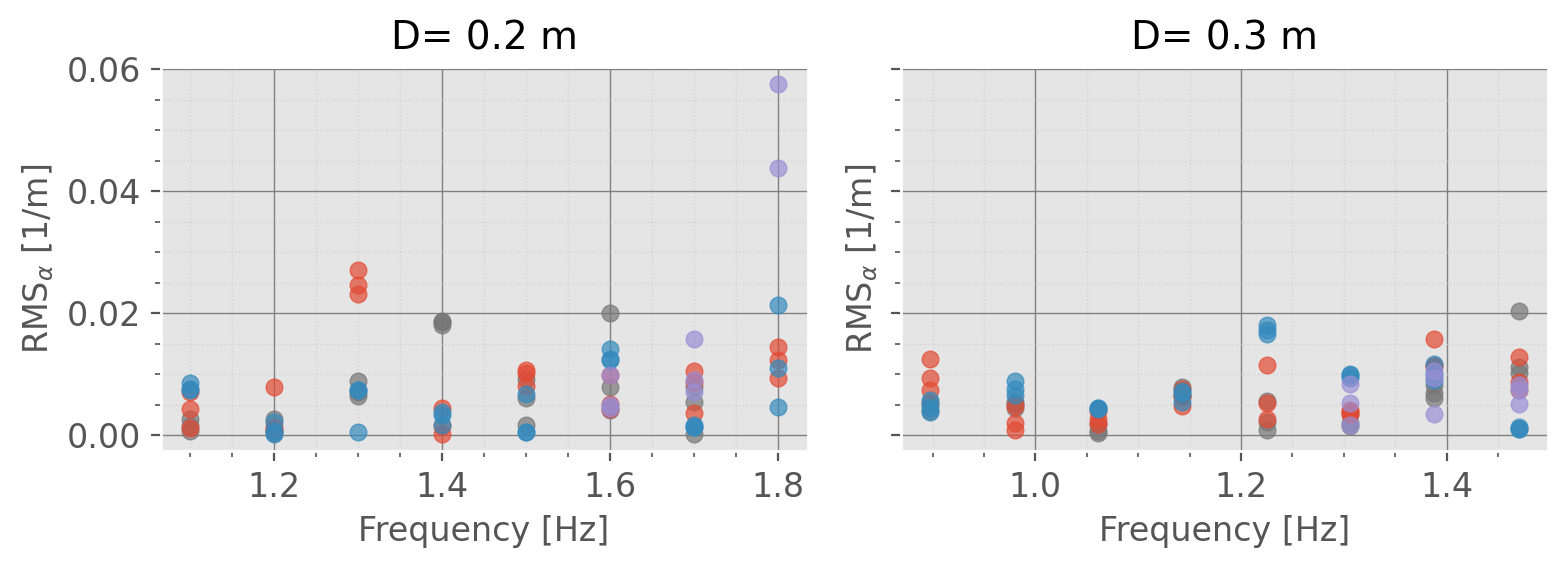

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

for level, sub in plates_20.groupby("volt_level"):
    ax[0].scatter(sub["frequency"], sub["rms_alpha"],
               marker='o',
               alpha=0.7,
               label=f'{level}',
               color=level_colors.get(level, "gray"))

for level, sub in plates_30.groupby("volt_level"):
    ax[1].scatter(sub["frequency"], sub["rms_alpha"],
            alpha=0.7,
               marker='o',
               color=level_colors.get(level, "gray"))
    
ax[0].set_xlabel('Frequency [Hz]')
ax[0].set_ylabel(r'RMS$_{\alpha}$ [1/m]')
ax[0].set_title("D= 0.2 m")
ax[1].set_xlabel('Frequency [Hz]')
ax[1].set_ylabel(r'RMS$_{\alpha}$ [1/m]')
ax[1].set_title("D= 0.3 m")

for a in ax:
    a.minorticks_on()
    a.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
    a.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray') 
plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/rms_alpha_obs_vs_theory.png", dpi=300)

In [13]:
print(f"Mean RMS for D=0.2 m: {plates_20['rms_alpha'].mean():.4f} 1/m")
print(f"Mean RMS for D=0.3 m: {plates_30['rms_alpha'].mean():.4f} 1/m")

print(f"Max RMS for D=0.2 m: {plates_20['rms_alpha'].max():.4f} 1/m")
print(f"Max RMS for D=0.3 m: {plates_30['rms_alpha'].max():.4f} 1/m")

print(f"Min RMS for D=0.2 m: {plates_20['rms_alpha'].min():.4f} 1/m")
print(f"Min RMS for D=0.3 m: {plates_30['rms_alpha'].min():.4f} 1/m")

print(f"Median RMS for D=0.2 m: {plates_20['rms_alpha'].median():.4f} 1/m")
print(f"Median RMS for D=0.3 m: {plates_30['rms_alpha'].median():.4f} 1/m")

Mean RMS for D=0.2 m: 0.0084 1/m
Mean RMS for D=0.3 m: 0.0066 1/m
Max RMS for D=0.2 m: 0.0576 1/m
Max RMS for D=0.3 m: 0.0203 1/m
Min RMS for D=0.2 m: 0.0002 1/m
Min RMS for D=0.3 m: 0.0004 1/m
Median RMS for D=0.2 m: 0.0071 1/m
Median RMS for D=0.3 m: 0.0058 1/m


In [14]:
# Behold alle rader der frequency IKKE er 1.7 eller 1.8
pl_20 = plates_20[~plates_20["frequency"].isin([1.7, 1.8])]
pl_30 = plates_30[~plates_30["frequency"].isin([1.388, 1.470])]

a_ratio_20 = np.mean(a_theory_20[:-2]) / np.mean(pl_20['alpha_plates'])
a_ratio_30 = np.mean(a_theory_30[:-2]) / np.mean(pl_30['alpha_plates'])

# How much bigger is the theoretical damping compared to the observed damping, on average (excluding the two highest frequencies)?
perc_20 = (a_ratio_20 - 1) * 100
perc_30 = (a_ratio_30 - 1) * 100

print(f"The theoretical damping is on average {perc_20:.1f}% larger than the observed damping for D=0.2 m (excluding the two highest frequencies).")
print(f"The theoretical damping is on average {perc_30:.1f}% larger than the observed damping for D=0.3 m (excluding the two highest frequencies).")

The theoretical damping is on average 15.2% larger than the observed damping for D=0.2 m (excluding the two highest frequencies).
The theoretical damping is on average 47.1% larger than the observed damping for D=0.3 m (excluding the two highest frequencies).


In [15]:
R_theory_20_eq28 = []
R_theory_30_eq28 = []

for k, f in zip(k_20, f_20):
    R_theory_20_eq28.append(robin_parameter_eq_28(f=f, k=k, a=a_theory_20[k_20.index(k)], H=H_20))

for k, f in zip(k_30, f_30):
    R_theory_30_eq28.append(robin_parameter_eq_28(f=f, k=k, a=a_theory_30[k_30.index(k)], H=H_30))

In [16]:
def add_R_eq28(df, H, D):
    R_eq28 = []
    for idx, row in df.iterrows():
        f = row['frequency']
        k = estimate_wavenumber(f, D)
        a = row['alpha']
        R_eq28.append(robin_parameter_eq_28(f=f, k=k, a=a, H=H))
    df['R_eq28'] = R_eq28
    return df

In [17]:
plates_20 = add_R_eq28(plates_20, H_20, D_20)
plates_30 = add_R_eq28(plates_30, H_30, D_30)
no_plates_20 = add_R_eq28(no_plates_20, H_20, D_20)
no_plates_30 = add_R_eq28(no_plates_30, H_30, D_30)

In [18]:
plates_20['R_plates_28'] = plates_20['R_eq28'] - no_plates_20['R_eq28']
plates_30['R_plates_28'] = plates_30['R_eq28'] - no_plates_30['R_eq28']

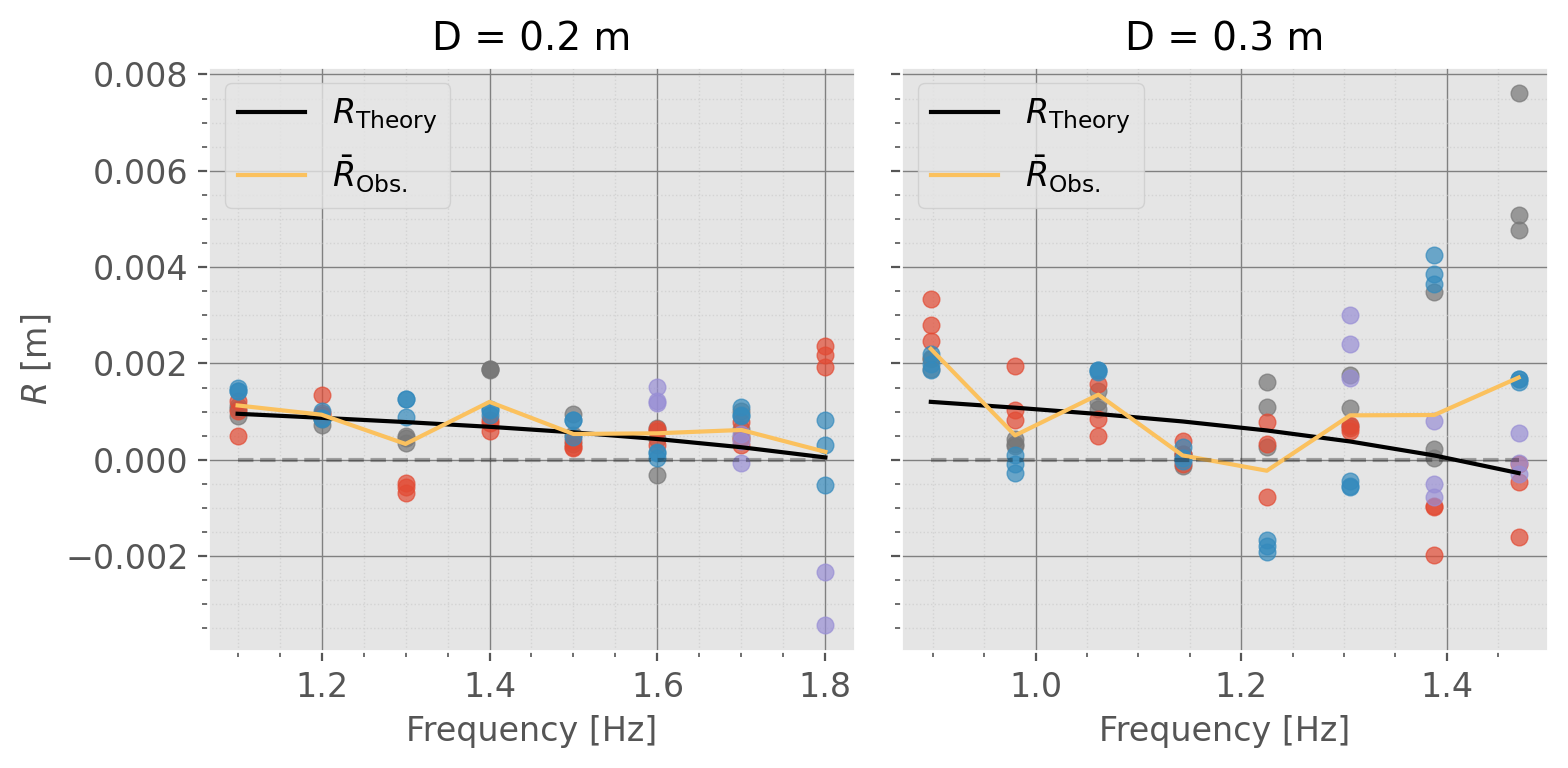

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

for level, sub in plates_20.groupby("volt_level"):
    ax[0].scatter(sub["frequency"], sub["R_plates_28"],
               marker='o',
               alpha=0.7,
               color=level_colors.get(level, "gray"))

for level, sub in plates_30.groupby("volt_level"):
    ax[1].scatter(sub["frequency"], sub["R_plates_28"],
            alpha=0.7,
               marker='o',
               color=level_colors.get(level, "gray"))

ax[0].plot(f_20, R_theory_20_eq28, '-', color='black', label=r'$R_{\text{Theory}}$')
ax[1].plot(f_30, R_theory_30_eq28, '-', color='black', label=r'$R_{\text{Theory}}$')

ax[0].plot(f_20, plates_20.groupby('frequency')['R_plates_28'].mean(), color='C4', label=r'$\bar{R}_{\text{Obs.}}$')
ax[1].plot(f_30, plates_30.groupby('frequency')['R_plates_28'].mean(), color='C4', label=r'$\bar{R}_{\text{Obs.}}$')

ax[0].hlines(0, f_20.min(), f_20.max(), colors='k', linestyles='dashed', alpha=0.3)
ax[1].hlines(0, f_30.min(), f_30.max(), colors='k', linestyles='dashed', alpha=0.3)

ax[0].set_title('D = 0.2 m')
ax[1].set_title('D = 0.3 m')

ax[0].set_xlabel('Frequency [Hz]')
ax[1].set_xlabel('Frequency [Hz]')
ax[0].set_ylabel(r'$R$ [m]')
ax[0].legend(loc='upper left')
ax[1].legend(loc='upper left')

for a in ax:
    a.minorticks_on()
    a.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
    a.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray') 

plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/R_obs_vs_theory_eq28.png", dpi=300)

In [20]:
# Exclude the two highest frequencies
plates_20_excl = plates_20[~plates_20["frequency"].isin([1.7, 1.8])]
plates_30_excl = plates_30[~plates_30["frequency"].isin([1.388, 1.470])]

print(f'Mean R_20: {np.mean(plates_20_excl["R_plates_28"])}')
print(f'Mean R_30: {np.mean(plates_30_excl["R_plates_28"])}')

print(f'Mean theoretical R_20 (Eq. 28): {np.mean(R_theory_20_eq28[:-2])}')
print(f'Mean theoretical R_30 (Eq. 28): {np.mean(R_theory_30_eq28[:-2])}')

print(f'Damping ratio for R_20: {1 - np.mean(plates_20_excl["R_plates_28"]) / np.mean(R_theory_20_eq28[:-2])}')
print(f'Damping ratio for R_30: {1 - np.mean(plates_30_excl["R_plates_28"]) / np.mean(R_theory_30_eq28[:-2])}')

Mean R_20: 0.0007679036928305828
Mean R_30: 0.0008295782176563226
Mean theoretical R_20 (Eq. 28): 0.0007155511916047116
Mean theoretical R_30 (Eq. 28): 0.000836466522622193
Damping ratio for R_20: -0.07316387959394532
Damping ratio for R_30: 0.008235003768323756


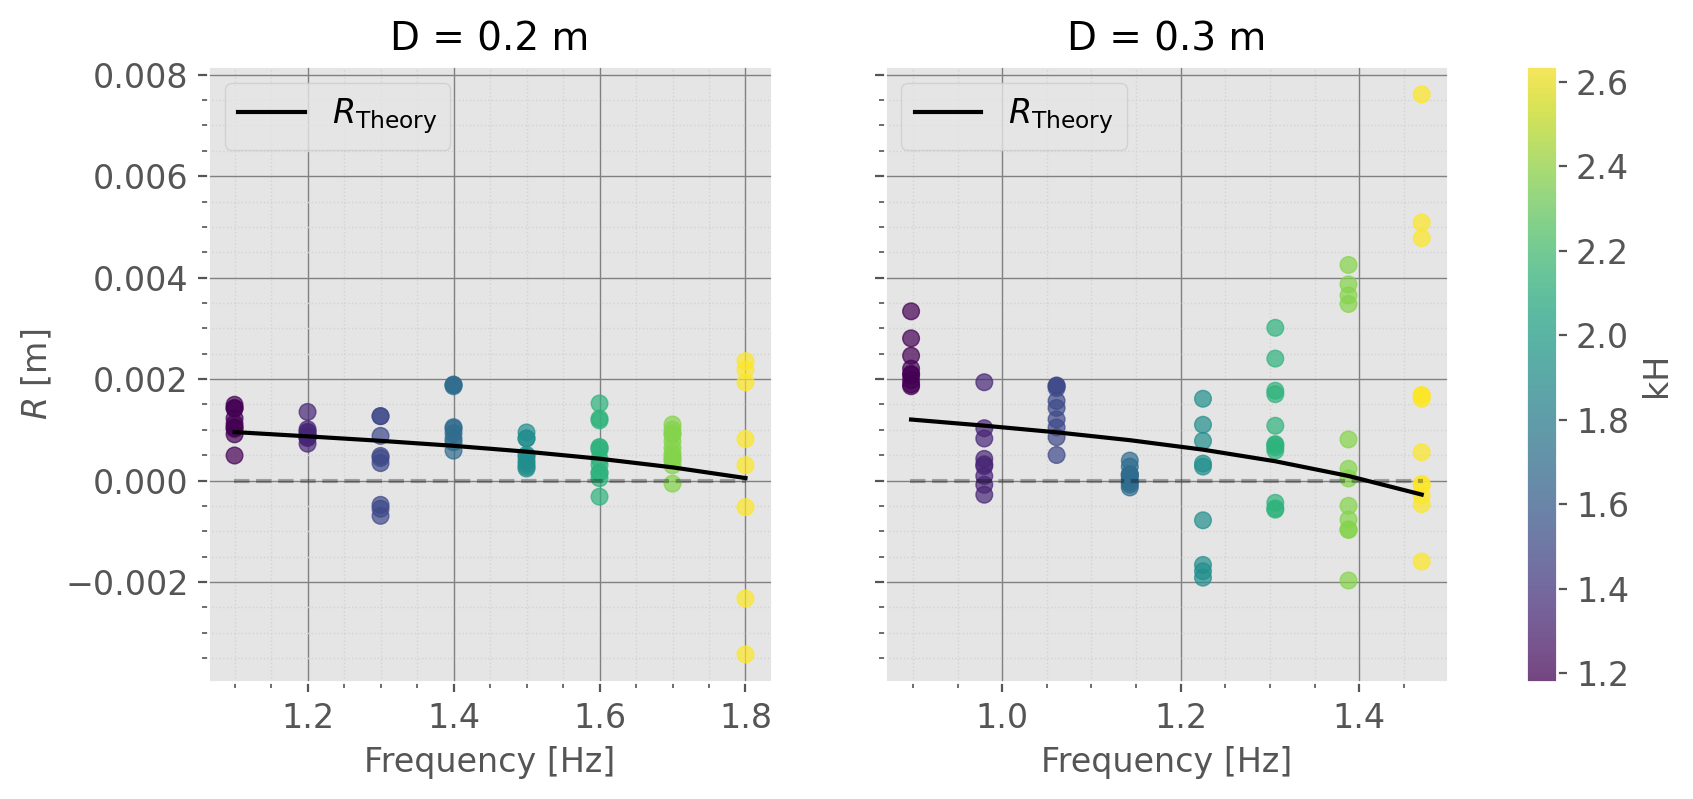

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Choose a colormap
cmap = "viridis"

# Get global min/max of kH to keep color scale consistent
kH_min = min(plates_20["kH"].min(), plates_30["kH"].min())
kH_max = max(plates_20["kH"].max(), plates_30["kH"].max())

for level, sub in plates_20.groupby("volt_level"):
    sc0 = ax[0].scatter(
        sub["frequency"],
        sub["R_plates_28"],
        marker="o",
        alpha=0.7,
        c=sub["kH"],          # color by kH
        cmap=cmap,
        vmin=kH_min, vmax=kH_max,
    )

for level, sub in plates_30.groupby("volt_level"):
    sc1 = ax[1].scatter(
        sub["frequency"],
        sub["R_plates_28"],
        marker="o",
        alpha=0.7,
        c=sub["kH"],          # color by kH
        cmap=cmap,
        vmin=kH_min, vmax=kH_max,
    )

ax[0].plot(f_20, R_theory_20_eq28, "-", color="black", label=r"$R_{\text{Theory}}$")
ax[1].plot(f_30, R_theory_30_eq28, "-", color="black", label=r"$R_{\text{Theory}}$")

ax[0].hlines(0, 1.099, 1.801, colors="k", linestyles="dashed", alpha=0.3)
ax[1].hlines(0, 0.897, 1.471, colors="k", linestyles="dashed", alpha=0.3)

ax[0].set_title("D = 0.2 m")
ax[1].set_title("D = 0.3 m")

ax[0].set_xlabel("Frequency [Hz]")
ax[1].set_xlabel("Frequency [Hz]")
ax[0].set_ylabel(r"$R$ [m]")
ax[0].legend(loc="upper left")
ax[1].legend(loc="upper left")

for a in ax:
    a.minorticks_on()
    a.grid(which="major", linestyle="-", linewidth="0.5", color="gray")
    a.grid(which="minor", linestyle=":", linewidth="0.5", color="lightgray")

# Add a single colorbar for kH
cbar = fig.colorbar(sc0, ax=ax, label="kH")

plt.savefig(
    "/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/R_obs_vs_theory_eq28.png",
    dpi=300,
)

In [23]:
# RMS of the difference between observed and theoretical damping coefficients
rms_20_eq28 = []
for idx, f in enumerate(f_20):
    obs = plates_20.loc[plates_20['frequency'] == f, 'R_plates_28'].values
    for val in obs:
        rms_20_eq28.append(np.sqrt((val - R_theory_20_eq28[idx]) ** 2))
plates_20['rms_R_eq28'] = rms_20_eq28

rms_30_eq28 = []
for idx, f in enumerate(f_30):
    obs = plates_30.loc[plates_30['frequency'] == f, 'R_plates_28'].values
    for val in obs:
        rms_30_eq28.append(np.sqrt((val - R_theory_30_eq28[idx]) ** 2))
plates_30['rms_R_eq28'] = rms_30_eq28

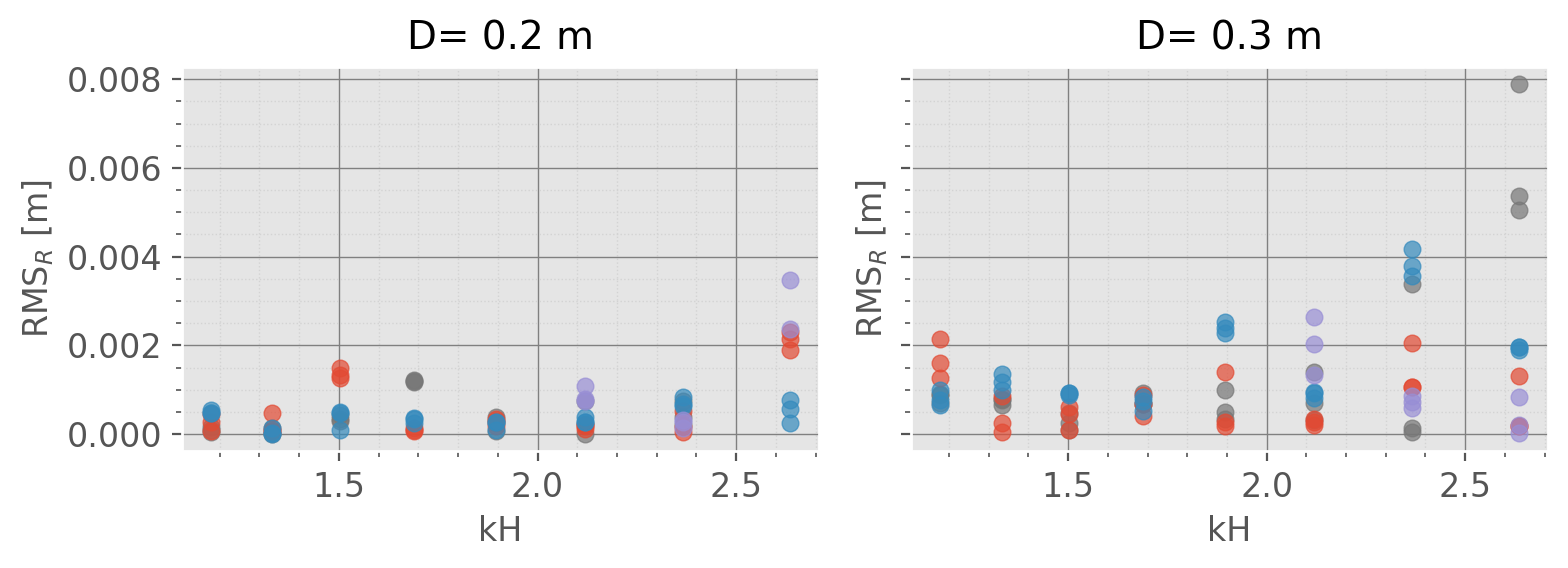

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

for level, sub in plates_20.groupby("volt_level"):
    ax[0].scatter(sub["kH"], sub["rms_R_eq28"],
               marker='o',
               alpha=0.7,
               label=f'{level}',
               color=level_colors.get(level, "gray"))

for level, sub in plates_30.groupby("volt_level"):
    ax[1].scatter(sub["kH"], sub["rms_R_eq28"],
            alpha=0.7,
               marker='o',
               color=level_colors.get(level, "gray"))
    
ax[0].set_xlabel('kH')
ax[0].set_ylabel(r'RMS$_{R}$ [m]')
ax[0].set_title("D= 0.2 m")
ax[1].set_xlabel('kH')
ax[1].set_ylabel(r'RMS$_{R}$ [m]')
ax[1].set_title("D= 0.3 m")

for a in ax:
    a.minorticks_on()
    a.grid(which='major', linestyle='-', linewidth='0.5', color='gray')
    a.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray') 
plt.tight_layout()
plt.savefig("/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/rms_R_obs_vs_theory_eq28.png", dpi=300)

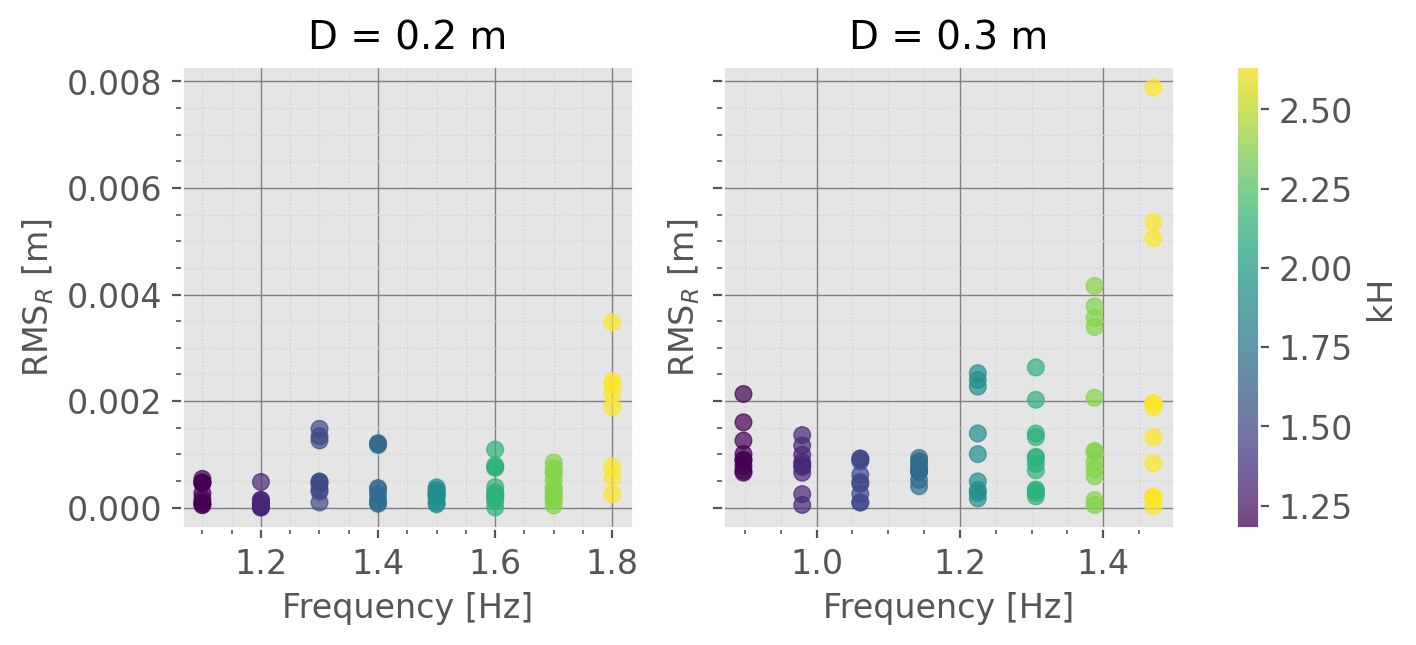

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

# Colormap and shared limits for kH
cmap = "viridis"
kH_min = min(plates_20["kH"].min(), plates_30["kH"].min())
kH_max = max(plates_20["kH"].max(), plates_30["kH"].max())

# Left panel: D = 0.2 m
for level, sub in plates_20.groupby("volt_level"):
    sc0 = ax[0].scatter(
        sub["frequency"],
        sub["rms_R_eq28"],
        marker="o",
        alpha=0.7,
        c=sub["kH"],
        cmap=cmap,
        vmin=kH_min,
        vmax=kH_max,
        label=f"{level}",   # volt_level in legend
    )

# Right panel: D = 0.3 m
for level, sub in plates_30.groupby("volt_level"):
    sc1 = ax[1].scatter(
        sub["frequency"],
        sub["rms_R_eq28"],
        marker="o",
        alpha=0.7,
        c=sub["kH"],
        cmap=cmap,
        vmin=kH_min,
        vmax=kH_max,
    )

ax[0].set_xlabel("Frequency [Hz]")
ax[0].set_ylabel(r"RMS$_{R}$ [m]")
ax[0].set_title("D = 0.2 m")

ax[1].set_xlabel("Frequency [Hz]")
ax[1].set_ylabel(r"RMS$_{R}$ [m]")
ax[1].set_title("D = 0.3 m")

for a in ax:
    a.minorticks_on()
    a.grid(which="major", linestyle="-", linewidth="0.5", color="gray")
    a.grid(which="minor", linestyle=":", linewidth="0.5", color="lightgray")

# Shared colorbar for kH
cbar = fig.colorbar(sc0, ax=ax, label="kH")

plt.savefig(
    "/Users/kjesta/Desktop/Master prosjekt/Figurer/obs_vs_teori/rms_R_obs_vs_theory_eq28.png",
    dpi=300,
)


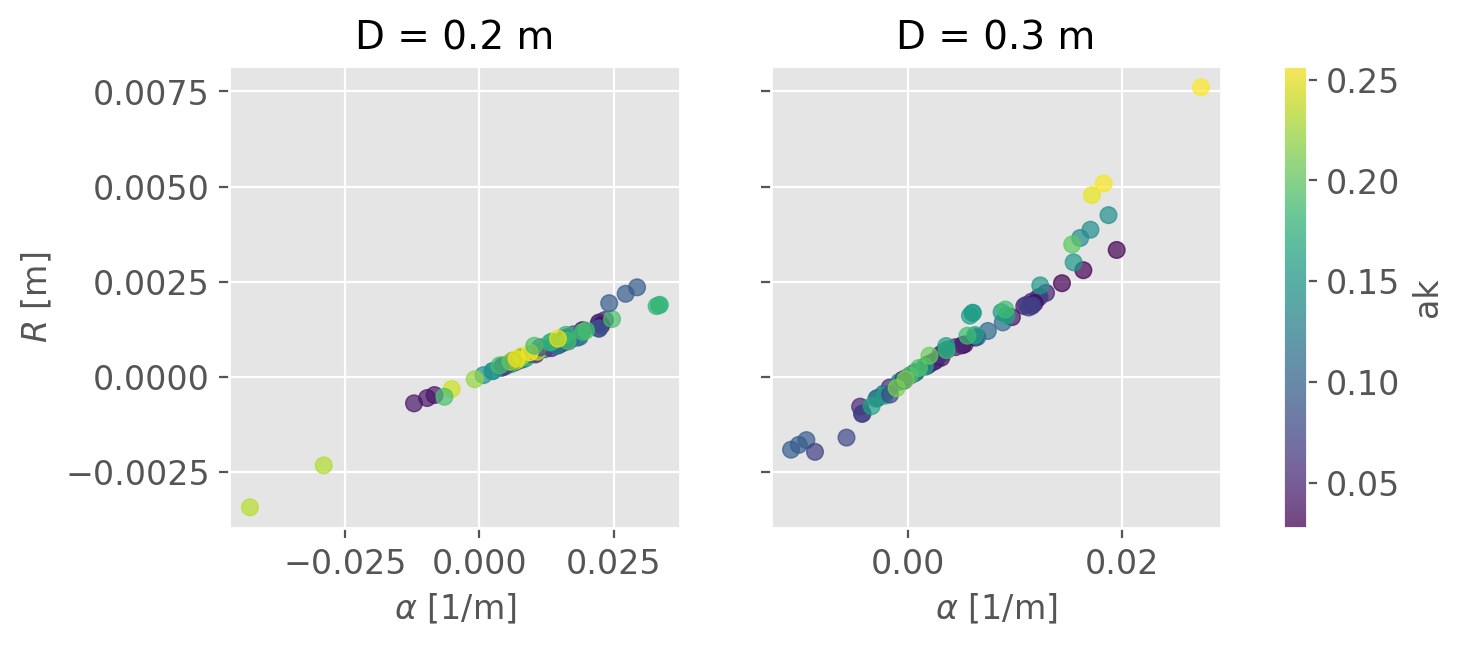

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

ax[0].scatter(plates_20['alpha_plates'], plates_20['R_plates_28'], c=plates_20['ak'], cmap='viridis', alpha=0.7)
ax[1].scatter(plates_30['alpha_plates'], plates_30['R_plates_28'], c=plates_30['ak'], cmap='viridis', alpha=0.7)

ax[0].set_xlabel(r'$\alpha$ [1/m]')
ax[0].set_ylabel(r'$R$ [m]')
ax[0].set_title('D = 0.2 m')
ax[1].set_xlabel(r'$\alpha$ [1/m]')
ax[1].set_title('D = 0.3 m')

cbar = fig.colorbar(ax[0].collections[0], ax=ax, label='ak')